In [1]:
import json, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'font.family': 'monospace',
})
C = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657']

with open('../models/nlp/entity_results.json',    encoding='utf-8') as f: results = json.load(f)
with open('../models/nlp/entity_best_model.json', encoding='utf-8') as f: best    = json.load(f)

print('Approaches trained:', list(results['val_results'].keys()))
print('Best approach     :', best['best_approach'])
print('Val macro F1      :', next(c['macro_f1'] for c in best['comparison'] if c['approach']==best['best_approach']))

Approaches trained: ['Regex', 'spaCy', 'GLiNER']
Best approach     : Regex
Val macro F1      : 0.8558


---
## 1. Silver Label Distribution

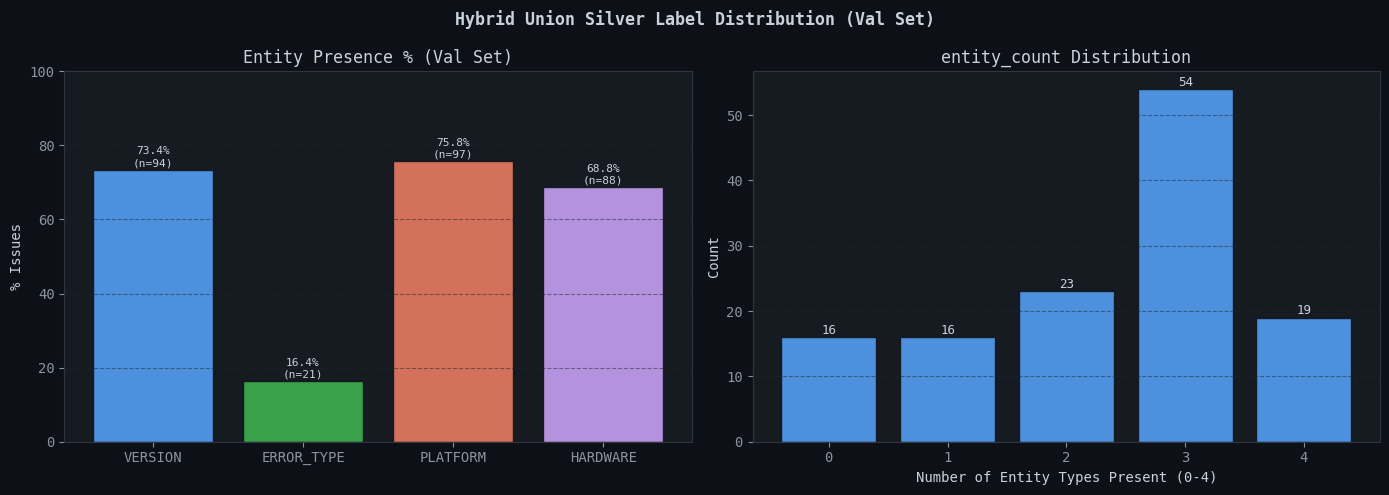

Total issues: 128
Issues with all 4 entities: 19
Issues with no entities:    16


In [2]:
import pickle, os

silver_path = '../models/nlp/entity_silver_labels_val.pkl'
if os.path.exists(silver_path):
    with open(silver_path, 'rb') as f:
        silver = pickle.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Hybrid Union Silver Label Distribution (Val Set)', fontweight='bold')

    # Bar chart — presence rates
    flag_cols = ['has_version','has_error_type','has_platform','has_hardware']
    labels    = ['VERSION','ERROR_TYPE','PLATFORM','HARDWARE']
    counts    = [silver[c].sum() for c in flag_cols]
    pcts      = [c/len(silver)*100 for c in counts]

    bars = axes[0].bar(labels, pcts, color=C[:4], alpha=0.85, edgecolor='#0d1117')
    axes[0].set_title('Entity Presence % (Val Set)')
    axes[0].set_ylabel('% Issues')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y')
    for bar, pct, cnt in zip(bars, pcts, counts):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{pct:.1f}%\n(n={cnt})', ha='center', fontsize=8)

    # Entity count distribution
    ec = silver['entity_count'].value_counts().sort_index()
    axes[1].bar(ec.index, ec.values, color=C[0], alpha=0.85, edgecolor='#0d1117')
    axes[1].set_title('entity_count Distribution')
    axes[1].set_xlabel('Number of Entity Types Present (0-4)')
    axes[1].set_ylabel('Count')
    axes[1].grid(axis='y')
    for i, v in zip(ec.index, ec.values):
        axes[1].text(i, v+0.5, str(v), ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'Total issues: {len(silver)}')
    print(f'Issues with all 4 entities: {(silver["entity_count"]==4).sum()}')
    print(f'Issues with no entities:    {(silver["entity_count"]==0).sum()}')
else:
    print('Silver labels not found. Run: python nlp/entity_extractor.py --mode train')

---
## 2. Approach Comparison — Macro F1

In [3]:
val_res = results['val_results']
approaches = list(val_res.keys())

print('=== APPROACH COMPARISON (Val Set) ===')
rows = []
for name, r in val_res.items():
    rows.append({
        'Approach':    name,
        'Macro P':     f"{r['macro_precision']:.4f}",
        'Macro R':     f"{r['macro_recall']:.4f}",
        'Macro F1':    f"{r['macro_f1']:.4f}",
    })
print(pd.DataFrame(rows).to_string(index=False))

=== APPROACH COMPARISON (Val Set) ===
Approach Macro P Macro R Macro F1
   Regex  1.0000  0.7690   0.8558
   spaCy  1.0000  0.7301   0.8295
  GLiNER  1.0000  0.7409   0.8494


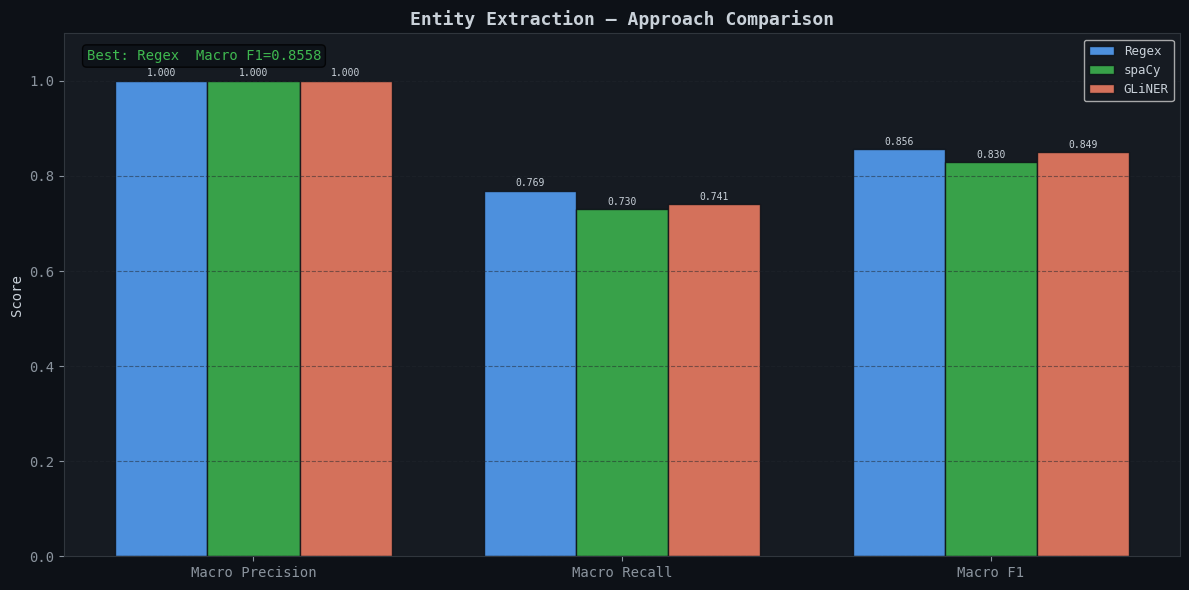

In [4]:
metrics_plot = ['macro_precision','macro_recall','macro_f1']
labels_plot  = ['Macro Precision','Macro Recall','Macro F1']
n = len(approaches)
x = np.arange(len(metrics_plot))
w = 0.75 / n

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, col) in enumerate(zip(approaches, C)):
    r      = val_res[name]
    vals   = [r.get(m, 0) for m in metrics_plot]
    offset = (i - n/2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w, label=name,
                    color=col, alpha=0.85, edgecolor='#0d1117')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Entity Extraction — Approach Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y')
best_f1 = next(c['macro_f1'] for c in best['comparison'] if c['approach']==best['best_approach'])
ax.text(0.02, 0.97, f'Best: {best["best_approach"]}  Macro F1={best_f1:.4f}',
        transform=ax.transAxes, fontsize=10, color='#3fb950', va='top',
        bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))
plt.tight_layout()
plt.show()

---
## 3. Per-Entity F1 Breakdown

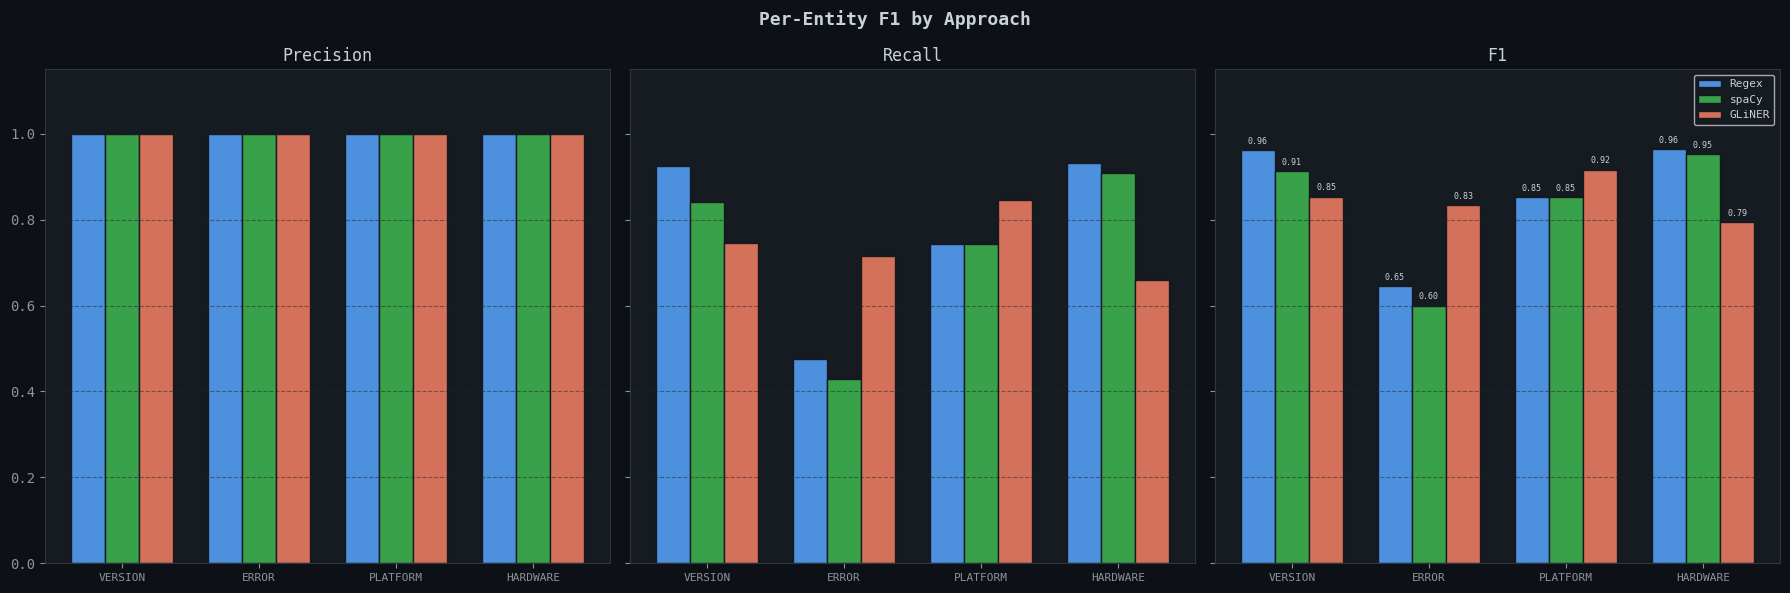

In [5]:
entity_types = ['version','error_type','platform','hardware']
n_approaches = len(approaches)
x = np.arange(len(entity_types))
w = 0.75 / n_approaches

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Per-Entity F1 by Approach', fontweight='bold', fontsize=13)

metric_names = ['precision','recall','f1']
metric_labels = ['Precision','Recall','F1']

for ax, metric, mlabel in zip(axes, metric_names, metric_labels):
    for i, (name, col) in enumerate(zip(approaches, C)):
        per_ent = val_res[name].get('per_entity', {})
        vals    = [per_ent.get(e, {}).get(metric, 0) for e in entity_types]
        offset  = (i - n_approaches/2 + 0.5) * w
        bars    = ax.bar(x + offset, vals, w, label=name if metric=='f1' else '',
                         color=col, alpha=0.85, edgecolor='#0d1117')
        if metric == 'f1':
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels(['VERSION','ERROR','PLATFORM','HARDWARE'], fontsize=8)
    ax.set_title(mlabel)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y')
    if metric == 'f1':
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Test Set Results

In [6]:
test_res = results.get('test_results', {})
if not test_res:
    print('No test results yet. Run:')
    print('  python nlp/entity_extractor.py --mode test')
else:
    print('=== TEST SET RESULTS ===')
    print(f'  Approach:    {test_res.get("approach_name", "N/A")}')
    print(f'  Macro F1:    {test_res.get("macro_f1", "N/A"):.4f}')
    print(f'  Macro P:     {test_res.get("macro_precision", "N/A"):.4f}')
    print(f'  Macro R:     {test_res.get("macro_recall", "N/A"):.4f}')
    print()
    print('  Per-entity:')
    for etype, m in test_res.get('per_entity', {}).items():
        print(f'    {etype:15s}: P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}')

    # Val vs Test gap
    best_name = best['best_approach']
    val_f1  = next((c['macro_f1'] for c in best['comparison'] if c['approach']==best_name), None)
    test_f1 = test_res.get('macro_f1')
    if val_f1 and test_f1:
        gap    = abs(val_f1 - test_f1)
        status = 'possible overfit' if gap > 0.05 else 'stable'
        print(f'\n  Val F1={val_f1:.4f}  Test F1={test_f1:.4f}  Gap={gap:.4f}  [{status}]')

=== TEST SET RESULTS ===
  Approach:    Regex [TEST]
  Macro F1:    0.8634
  Macro P:     1.0000
  Macro R:     0.7930

  Per-entity:
    version        : P=1.000  R=0.960  F1=0.980
    error_type     : P=1.000  R=0.406  F1=0.578
    platform       : P=1.000  R=0.844  F1=0.916
    hardware       : P=1.000  R=0.962  F1=0.980

  Val F1=0.8558  Test F1=0.8634  Gap=0.0076  [stable]


---
## 5. Entity Presence in Full Dataset

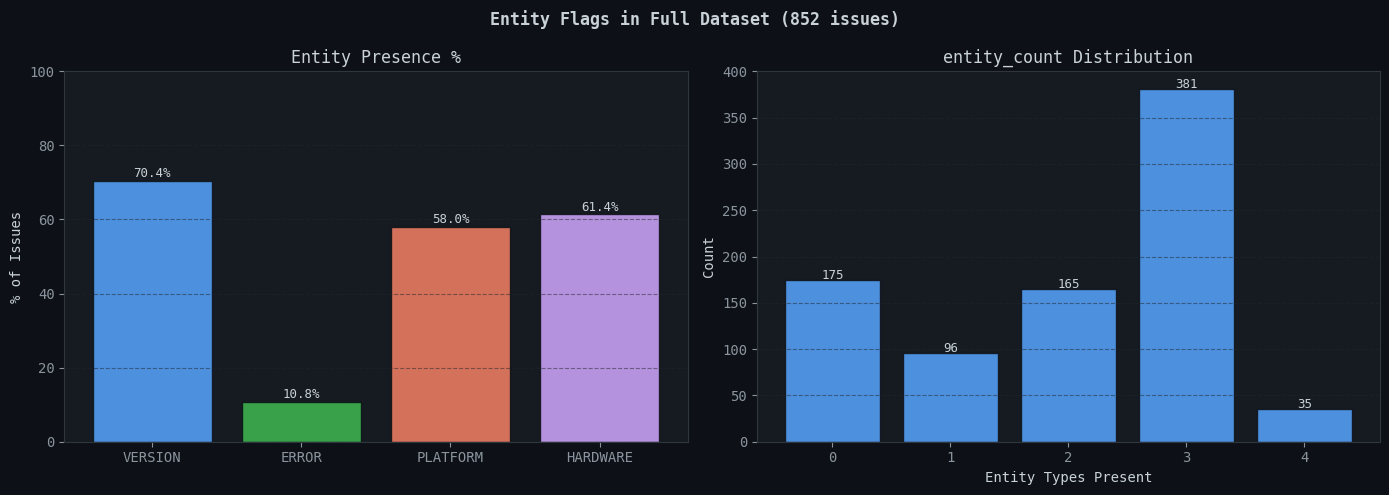

Entity co-occurrence (how often entities appear together):
  has_version + has_error_type: 69 (8.1%)
  has_version + has_platform: 476 (55.9%)
  has_version + has_hardware: 467 (54.8%)
  has_error_type + has_platform: 40 (4.7%)
  has_error_type + has_hardware: 67 (7.9%)
  has_platform + has_hardware: 399 (46.8%)


In [7]:
ci = pd.read_csv('../data/final/cleaned_issues.csv')
flag_cols = ['has_version','has_error_type','has_platform','has_hardware']

if all(c in ci.columns for c in flag_cols):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Entity Flags in Full Dataset (852 issues)', fontweight='bold')

    # Entity presence rates
    labels = ['VERSION','ERROR','PLATFORM','HARDWARE']
    pcts   = [ci[c].mean()*100 for c in flag_cols]
    bars   = axes[0].bar(labels, pcts, color=C[:4], alpha=0.85, edgecolor='#0d1117')
    axes[0].set_title('Entity Presence %')
    axes[0].set_ylabel('% of Issues')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y')
    for bar, pct in zip(bars, pcts):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{pct:.1f}%', ha='center', fontsize=9)

    # Entity count distribution
    ec = ci['entity_count'].value_counts().sort_index()
    axes[1].bar(ec.index, ec.values, color=C[0], alpha=0.85, edgecolor='#0d1117')
    axes[1].set_title('entity_count Distribution')
    axes[1].set_xlabel('Entity Types Present')
    axes[1].set_ylabel('Count')
    axes[1].grid(axis='y')
    for i, v in zip(ec.index, ec.values):
        axes[1].text(i, v+1, str(v), ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('Entity co-occurrence (how often entities appear together):')
    for i, c1 in enumerate(flag_cols):
        for c2 in flag_cols[i+1:]:
            both = (ci[c1]==1) & (ci[c2]==1)
            print(f'  {c1} + {c2}: {both.sum()} ({both.mean()*100:.1f}%)')
else:
    print('Entity flags not found. Run: python nlp/entity_extractor.py --mode generate')

---
## 6. Live Extraction Demo

In [8]:
from nlp.entity_extractor import extract_regex
import os

# Demo using regex (always available without dependencies)
test_cases = [
    'AttributeError in torch 2.1.0 on ubuntu 22.04 with CUDA 11.8',
    'Build fails on windows 11 with missing DLL',
    'Getting OOM error when running on RTX 3090 with rocm backend',
    'vs code version: code 1.111.0 os version: linux x64',
    'Crash in extension version: 0.39.2',
    'Please add dark mode support',
]

print(f'{"Text":<55} {"VER":>4} {"ERR":>4} {"PLT":>4} {"HW":>4} {"#":>3}')
print('─' * 80)
for text in test_cases:
    e   = extract_regex(text)
    v   = '✓' if e['version']    else '✗'
    er  = '✓' if e['error_type'] else '✗'
    pl  = '✓' if e['platform']   else '✗'
    hw  = '✓' if e['hardware']   else '✗'
    cnt = sum([bool(e['version']),bool(e['error_type']),bool(e['platform']),bool(e['hardware'])])
    print(f'{text[:53]:<55} {v:>4} {er:>4} {pl:>4} {hw:>4} {cnt:>3}')
    # Show what was extracted
    for etype, vals in e.items():
        if vals:
            print(f'  {etype}: {vals[:3]}')

Text                                                     VER  ERR  PLT   HW   #
────────────────────────────────────────────────────────────────────────────────
AttributeError in torch 2.1.0 on ubuntu 22.04 with CU      ✓    ✓    ✓    ✓   4
  version: ['torch 2.1.0', 'cuda 11.8', '2.1.0']
  error_type: ['attributeerror']
  platform: ['ubuntu']
  hardware: ['cuda']
Build fails on windows 11 with missing DLL                 ✗    ✗    ✓    ✗   1
  platform: ['windows']
Getting OOM error when running on RTX 3090 with rocm       ✗    ✓    ✗    ✓   2
  error_type: ['oom']
  hardware: ['rtx', 'rocm', '3090']
vs code version: code 1.111.0 os version: linux x64        ✓    ✗    ✓    ✗   2
  version: ['code 1.111.0', '1.111.0', '1.111']
  platform: ['linux']
Crash in extension version: 0.39.2                         ✓    ✗    ✗    ✗   1
  version: ['version: 0.39.2', '0.39.2', '0.39']
Please add dark mode support                               ✗    ✗    ✗    ✗   0


---
## 7. Best Model Summary

In [9]:
best_name = best['best_approach']
best_comp = next(c for c in best['comparison'] if c['approach'] == best_name)

print('=' * 60)
print('BEST APPROACH SUMMARY')
print('=' * 60)
print(f'  Approach:          {best_name}')
print(f'  Selection metric:  {best["selection_metric"]}')
print(f'  Reason:            {best["selection_reason"]}')
print()
print('  Val Performance:')
print(f'    Macro F1:        {best_comp["macro_f1"]:.4f}')
print(f'    Macro Precision: {best_comp["macro_precision"]:.4f}')
print(f'    Macro Recall:    {best_comp["macro_recall"]:.4f}')
print()
print('  Annotation strategy:')
print(f'    {best["annotation_strategy"]}')
print()
print('  Entity flags in RL state:')
for e in ['has_version','has_error_type','has_platform','has_hardware','entity_count']:
    print(f'    {e}')

BEST APPROACH SUMMARY
  Approach:          Regex
  Selection metric:  macro_f1
  Reason:            Macro F1 averaged across all 4 entity types. F1 chosen over precision because missing an entity (FN) is worse than a false positive — incomplete RL state is harder to recover from than a slightly noisy state.

  Val Performance:
    Macro F1:        0.8558
    Macro Precision: 1.0000
    Macro Recall:    0.7690

  Annotation strategy:
    Hybrid Union Silver Standard: has_entity=1 if Regex OR GLiNER detects entity. Covers structured template issues (Regex) and informal free-text issues (GLiNER).

  Entity flags in RL state:
    has_version
    has_error_type
    has_platform
    has_hardware
    entity_count


---
### Why These Three Approaches
- **Regex**: Character pattern matching — perfect for structured version numbers and closed vocabularies. Zero dependencies.
- **spaCy**: Token-level linguistic matching — captures multi-word entities like `python 3.10` as one unit. Uses context.
- **GLiNER**: Zero-shot neural NER — semantic understanding catches informal mentions (`my Mac`, `OOM`, `py3.9`).

